

**Pipeline**
1. Imports & device  
2. All shared definitions (encoding, model, dataset, train/test)  
3. Data preprocessing — 6 folds including Benchmark  
4. Physicochemical scale helper  
5. Best hyperparameter configuration  
6. Final model training  
7. TorchScript model export  
8. Benchmark evaluation & error annotation  
9. Metrics & confusion matrix  
10. Helix domain analysis  
11. Signal peptide length distribution  
12. Hydrophobicity analysis  
13. Amino acid frequency analysis  
14. Sequence logos  
15. False positive rate  
16. Taxonomic analysis

## 1. Imports & Device

In [9]:
import os
import gc
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from Bio.SeqUtils.ProtParam import ProtParamData, ProteinAnalysis
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    matthews_corrcoef, precision_score, recall_score,
)
from torch.utils.data import DataLoader, Dataset

# Use GPU if available — all models and tensors are moved here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Create output folder for all saved figures
os.makedirs("model_evaluation", exist_ok=True)
print("Output folder: model_evaluation/")

Device: cpu
Output folder: model_evaluation/


## 2. Shared Definitions

All encoding functions, the model class, the dataset wrapper, and the
training/inference functions are defined here so this notebook requires
no external file dependencies.

In [10]:
# ── One-hot encoding ─────────────────────────────────────────────────────────

def _increase_lenseq(seq: str, target: int = 90) -> str:
    """Pad sequence with 'X' to reach target length. X encodes as all-zero vector."""
    return seq + "X" * (target - len(seq))


def one_hot_encoding(sequence: str) -> np.ndarray:
    """
    Convert an amino-acid sequence to a (len, 21) float32 binary matrix.
    Alphabet: A C D E F G H I K L M N P Q R S T V W Y X
    Unknown characters remain all-zero (safe fallback).
    """
    AA_ALPHABET = ["A","C","D","E","F","G","H","I","K","L",
                   "M","N","P","Q","R","S","T","V","W","Y","X"]
    aa_to_idx = {aa: i for i, aa in enumerate(AA_ALPHABET)}
    matrix = []
    for aa in sequence:
        one_hot = np.zeros(21, dtype=np.float32)
        idx = aa_to_idx.get(aa)
        if idx is not None:
            one_hot[idx] = 1.0
        matrix.append(one_hot)
    return np.array(matrix, dtype=np.float32)


# ── Model ─────────────────────────────────────────────────────────────────────

class SP_NN(nn.Module):
    """
    Hybrid CNN-LSTM model for binary signal-peptide classification.

    Architecture:
        Conv1D (kernel=17, 64 maps) → LSTM (stacked) → BatchNorm
        → MLP (Linear-ReLU-Dropout) × n → Sigmoid
    """
    def __init__(self, input_size, hidden_sizes, lstm_hidden_size,
                 num_lstm_layers, output_size, dropout_p=0.5):
        super().__init__()
        # kernel=17 spans typical hydrophobic-core length of a signal peptide
        self.conv1 = nn.Conv1d(input_size, 64, kernel_size=17, padding="same")
        # Inter-layer dropout only valid when num_layers > 1
        lstm_dropout = dropout_p if num_lstm_layers > 1 else 0.0
        self.lstm = nn.LSTM(64, lstm_hidden_size, num_lstm_layers,
                            batch_first=True, dropout=lstm_dropout)
        # BatchNorm stabilises LSTM output distribution before the classifier
        self.bn = nn.BatchNorm1d(lstm_hidden_size)
        # Dynamic MLP head — depth and width driven by hidden_sizes list
        layers, cur = [], lstm_hidden_size
        for h in hidden_sizes:
            layers += [nn.Linear(cur, h), nn.ReLU(), nn.Dropout(p=dropout_p)]
            cur = h
        layers += [nn.Linear(cur, output_size), nn.Sigmoid()]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: [B, 90, 21]
        x = x.permute(0, 2, 1)      # Conv1d needs [B, C, L]
        x = self.conv1(x)           # → [B, 64, 90]
        x = x.permute(0, 2, 1)      # LSTM needs [B, L, C]
        out, _ = self.lstm(x)       # → [B, 90, hidden]
        out = out[:, -1, :]         # last time-step summarises full sequence
        out = self.bn(out)
        return self.mlp(out)        # → [B, 1] probability


# ── Dataset ───────────────────────────────────────────────────────────────────

class SignalDataset(Dataset):
    """
    Lazy-loading dataset wrapper.
    Stores raw NumPy arrays; converts to tensors only when a sample is requested.
    .copy() on the array prevents PyTorch's non-writable-tensor UserWarning.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_out = torch.from_numpy(self.X[idx].copy()).float()
        # .view(1) reshapes scalar label to [1] — matches model output shape [B,1]
        # required by BCELoss to avoid dimension mismatch
        y_out = torch.tensor(self.y[idx], dtype=torch.float32).view(1)
        return x_out, y_out


# ── Training loop ─────────────────────────────────────────────────────────────

def train_val(model, train_loader, val_loader, optimizer, criterion,
              epochs, patience, scorer=matthews_corrcoef,
              init_best_score=-1.0,
              output_transform=lambda x: (x > 0.5).float(),
              verbose=True):
    """
    Training + validation loop with early stopping and gradient clipping.

    Gradient clipping (max_norm=1.0): prevents exploding gradients in LSTMs.
    Early stopping: halts when validation MCC stops improving for `patience` epochs.
    Best-model tracking: returns weights of the best epoch, not the final one.

    Returns state_dict of the best-scoring epoch.
    """
    best_val_score = init_best_score
    epochs_no_improve = 0
    best_state = None

    for epoch in range(epochs):

        # ── Training phase ────────────────────────────────────────────────
        model.train()   # enables Dropout, updates BatchNorm running stats
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            # Rescale gradients if norm exceeds 1.0 — critical for LSTM stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss = loss.item()

        # ── Validation phase ──────────────────────────────────────────────
        model.eval()    # disables Dropout, freezes BatchNorm stats
        val_preds, val_labels = [], []
        with torch.no_grad():   # skip autograd — saves memory during validation
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = output_transform(model(batch_X))
                val_preds.extend(preds.cpu().numpy().flatten())
                val_labels.extend(batch_y.cpu().numpy().flatten())

        val_score = scorer(val_labels, val_preds)

        if verbose:
            print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}  Val MCC: {val_score:.4f}")

        # ── Early stopping logic ──────────────────────────────────────────
        if val_score > best_val_score:
            best_val_score = val_score
            epochs_no_improve = 0
            best_state = model.state_dict()   # save best checkpoint in RAM
            if verbose:
                print(f"  ✓ Improved to {best_val_score:.4f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch+1}")
                break

    return best_state


# ── Inference ─────────────────────────────────────────────────────────────────

def test(model, test_loader, scorer=matthews_corrcoef,
         output_transform=lambda x: (x > 0.5).float()):
    """
    Evaluate a trained model on a test set.
    Returns (score, all_preds) — MCC scalar and full binary prediction list.
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = output_transform(model(batch_X))
            # CPU conversion required before numpy — sklearn rejects CUDA tensors
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(batch_y.cpu().numpy().flatten())
    return scorer(all_labels, all_preds), all_preds

print("All definitions loaded successfully.")

All definitions loaded successfully.


## 3. Data Preprocessing

Extends the standard 5-fold encoding to also include the **Benchmark** fold —
an independent held-out set never seen during training or hyperparameter search.

| Index | Fold | Role |
|---|---|---|
| 0–3 | 1–4 | Training |
| 4 | 5 | Validation (early stopping monitor) |
| 5 | Benchmark | Final evaluation only |

In [11]:
def create_one_hot_sets_with_benchmark(dataset: pd.DataFrame) -> list:
    """
    Encode all 6 dataset partitions including the independent Benchmark fold.
    Returns list of 6 (X, y) tuples — indices 0-4 are CV folds, index 5 is Benchmark.
    """
    set_results = []
    for fold_id in ["1", "2", "3", "4", "5", "Benchmark"]:
        subset = dataset.query(f"Set == '{fold_id}'")
        X_list, y_list = [], []
        for _, row in subset.iterrows():
            seq = row["Sequence"]
            # Truncate at 90 residues (preserves N-terminus) or pad short sequences
            seq = seq[:90] if len(seq) >= 90 else _increase_lenseq(seq)
            X_list.append(one_hot_encoding(seq))
            y_list.append(1 if row["Class"] == "Positive" else 0)
        set_results.append((
            np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
        ))
    return set_results

# Load dataset and encode all folds
dataset  = pd.read_csv("../2.Data_Preparation/train_bench.tsv", sep="\t")
all_data = create_one_hot_sets_with_benchmark(dataset)

for i, (X, y) in enumerate(all_data):
    label = f"Fold {i+1}" if i < 5 else "Benchmark"
    print(f"  {label:12s}: X={X.shape}  positives={int(y.sum())}/{len(y)}")

  Fold 1      : X=(1603, 90, 21)  positives=174/1603
  Fold 2      : X=(1603, 90, 21)  positives=174/1603
  Fold 3      : X=(1603, 90, 21)  positives=174/1603
  Fold 4      : X=(1603, 90, 21)  positives=174/1603
  Fold 5      : X=(1609, 90, 21)  positives=178/1609
  Benchmark   : X=(2006, 90, 21)  positives=219/2006


## 4. Physicochemical Scale Helper

Used in section 12 to compute Miyazawa hydrophobicity over the annotated
signal-peptide region for each Positive entry.

In [12]:
def get_scale_feature(seq: str, scale, window: int, output_type: str) -> float:
    """
    Compute a sliding-window physicochemical profile and return mean or max.

    Parameters
    ----------
    seq         : clean amino-acid sequence
    scale       : ProtParamData attribute name (str) or custom dict
    window      : sliding-window width — capped to sequence length automatically
    output_type : 'mean' or 'max'
    """
    analysis = ProteinAnalysis(seq)
    effective_window = min(window, len(seq))   # guard against short sequences
    if isinstance(scale, dict):
        profile = analysis.protein_scale(scale, effective_window, edge=1)
    else:
        profile = analysis.protein_scale(
            getattr(ProtParamData, scale), effective_window, edge=1)
    return statistics.mean(profile) if output_type == "mean" else max(profile)

## 5. Best Hyperparameter Configuration

Retrieved from the best trial of the Ray Tune search in `lstm.ipynb`
(15 trials, metric: average 5-fold MCC).

### Architecture insight — "Hourglass" MLP head
The selected topology `[256 → 128 → 64 → 1024]` compresses features to a
64-dimensional bottleneck then expands to 1024 before the final linear layer.
This suggests that projecting compressed representations into a higher-dimensional
space improves class separation.

| Parameter | Value |
|---|---|
| LSTM layers | 2 |
| LSTM hidden size | 128 |
| MLP hidden layers | [256, 128, 64, 1024] |
| Dropout | ≈ 0.498 |
| Learning rate | ≈ 2.86 × 10⁻⁴ |
| Batch size | 20 |

In [13]:
# Best configuration from Ray Tune HPO (lstm.ipynb, 15 trials)
BEST_CONFIG = {
    "num_layers":       4,
    "hidden_sizes":     [256, 128, 64, 1024],   # hourglass MLP topology
    "dropout":          0.4980673167779849,
    "lr":               0.00028585527498522286,
    "batch_size":       20,
    "num_lstm_layers":  2,
    "lstm_hidden_size": 128,
}
print("Config loaded:", BEST_CONFIG)

Config loaded: {'num_layers': 4, 'hidden_sizes': [256, 128, 64, 1024], 'dropout': 0.4980673167779849, 'lr': 0.00028585527498522286, 'batch_size': 20, 'num_lstm_layers': 2, 'lstm_hidden_size': 128}


## 6. Final Model Training

In [14]:
# ── Data splits ──────────────────────────────────────────────────────────────
TRAINING_INDICES = [0, 1, 2, 3]   # folds 1-4
VALIDATION_INDEX = 4               # fold 5  — used for early stopping only
BENCHMARK_INDEX  = 5               # fully independent, never seen during training

x_train = np.concatenate([all_data[j][0] for j in TRAINING_INDICES])
y_train = np.concatenate([all_data[j][1] for j in TRAINING_INDICES])
x_val,  y_val  = all_data[VALIDATION_INDEX]
x_test, y_test = all_data[BENCHMARK_INDEX]

print(f"Training  : {x_train.shape[0]} samples")
print(f"Validation: {x_val.shape[0]} samples")
print(f"Benchmark : {x_test.shape[0]} samples")

# ── DataLoaders ───────────────────────────────────────────────────────────────
batch = BEST_CONFIG["batch_size"]
train_loader = DataLoader(SignalDataset(x_train, y_train), batch_size=batch, shuffle=True)
val_loader   = DataLoader(SignalDataset(x_val,   y_val),   batch_size=batch)
test_loader  = DataLoader(SignalDataset(x_test,  y_test),  batch_size=batch)

# ── Model instantiation ───────────────────────────────────────────────────────
model = SP_NN(
    input_size=21,
    hidden_sizes=BEST_CONFIG["hidden_sizes"],
    lstm_hidden_size=BEST_CONFIG["lstm_hidden_size"],
    num_lstm_layers=BEST_CONFIG["num_lstm_layers"],
    output_size=1,
    dropout_p=BEST_CONFIG["dropout"],
).to(device)

optimizer = optim.Adam(model.parameters(), lr=BEST_CONFIG["lr"])
criterion = nn.BCELoss()   # binary cross-entropy for binary classification

# ── Train ─────────────────────────────────────────────────────────────────────
best_state = train_val(
    model, train_loader, val_loader,
    optimizer, criterion,
    epochs=100,    # maximum; early stopping will typically trigger well before
    patience=20,   # stop after 20 epochs with no MCC improvement
)

# Load best-epoch weights back into the model before evaluation
model.load_state_dict(best_state)

mcc, bench_pred = test(model, test_loader)
print(f"\nMCC on benchmark set: {mcc:.4f}")

Training  : 6412 samples
Validation: 1609 samples
Benchmark : 2006 samples
Epoch [1/100]  Loss: 0.5286  Val MCC: 0.0000
  ✓ Improved to 0.0000
Epoch [2/100]  Loss: 0.1170  Val MCC: 0.0000
Epoch [3/100]  Loss: 0.2068  Val MCC: 0.0000
Epoch [4/100]  Loss: 0.5660  Val MCC: 0.0000
Epoch [5/100]  Loss: 0.1345  Val MCC: 0.0000
Epoch [6/100]  Loss: 0.1056  Val MCC: 0.0000
Epoch [7/100]  Loss: 0.1913  Val MCC: 0.0000
Epoch [8/100]  Loss: 1.0574  Val MCC: 0.0000
Epoch [9/100]  Loss: 0.3813  Val MCC: 0.0000
Epoch [10/100]  Loss: 0.2705  Val MCC: 0.0000
Epoch [11/100]  Loss: 0.5474  Val MCC: 0.0000
Epoch [12/100]  Loss: 0.7142  Val MCC: 0.0000
Epoch [13/100]  Loss: 0.1191  Val MCC: 0.0000
Epoch [14/100]  Loss: 0.1136  Val MCC: 0.0000
Epoch [15/100]  Loss: 0.2422  Val MCC: 0.5073
  ✓ Improved to 0.5073
Epoch [16/100]  Loss: 0.1344  Val MCC: 0.6744
  ✓ Improved to 0.6744
Epoch [17/100]  Loss: 0.2266  Val MCC: 0.4791
Epoch [18/100]  Loss: 0.0114  Val MCC: 0.7685
  ✓ Improved to 0.7685
Epoch [19/100]

## 7. TorchScript Model Export

We use **JIT tracing** to produce a standalone `.pt` file containing both
architecture and weights — no source code needed to reload it.

`model.eval()` before tracing permanently disables Dropout in the saved model,
ensuring deterministic inference.

In [15]:
model.eval()   # disables Dropout and freezes BatchNorm before tracing

# Dummy input matching the expected shape: [batch=1, length=90, channels=21]
dummy_input  = torch.randn(1, 90, 21).to(device)
traced_model = torch.jit.trace(model, dummy_input)
torch.jit.save(traced_model, "SignalPeptideLSTM.pt")
print("Model saved to SignalPeptideLSTM.pt")

# ── Verify JIT model produces identical results ───────────────────────────────
jit_model = torch.jit.load("SignalPeptideLSTM.pt")
mcc_jit, bench_pred = test(jit_model, test_loader)
print(f"MCC from JIT model : {mcc_jit:.4f}  (should match {mcc:.4f})")

Model saved to SignalPeptideLSTM.pt
MCC from JIT model : 0.9323  (should match 0.9323)


## 8. Error Identification & Benchmark Annotation

Each benchmark entry is labelled:

| Label | Meaning |
|---|---|
| **TP** | Signal peptide correctly identified |
| **TN** | Non-signal correctly classified |
| **FP** | Non-signal wrongly predicted as signal |
| **FN** | Real signal peptide missed by the model |

In [16]:
# Reset index so iloc positions align with prediction list indices
benchmark = dataset.query("Set == 'Benchmark'").reset_index(drop=True)

# Sanity check: prediction vector must match benchmark length exactly
print(f"Prediction vector : {len(bench_pred)}")
print(f"Benchmark rows    : {len(benchmark)}")
assert len(bench_pred) == len(benchmark), "Length mismatch — check fold encoding!"

# ── Collect error indices ─────────────────────────────────────────────────────
false_positives_idx = []
false_negatives_idx = []
for i in range(len(y_test)):
    if bench_pred[i] == 0 and y_test[i] == 1:
        false_negatives_idx.append(i)   # missed signal peptide
    elif bench_pred[i] == 1 and y_test[i] == 0:
        false_positives_idx.append(i)   # false alarm

# ── Annotate dataframe ────────────────────────────────────────────────────────
classification_col = []
for i in range(len(benchmark)):
    if   i in false_positives_idx: classification_col.append("FP")
    elif i in false_negatives_idx: classification_col.append("FN")
    elif benchmark.iloc[i]["Class"] == "Negative": classification_col.append("TN")
    else: classification_col.append("TP")

prediction_dataset = benchmark.copy()
prediction_dataset["Prediction"] = classification_col

print("\nPrediction breakdown:")
print(prediction_dataset["Prediction"].value_counts().to_string())

Prediction vector : 2006
Benchmark rows    : 2006

Prediction breakdown:
Prediction
TN    1779
TP     201
FN      18
FP       8


## 9. Performance Metrics & Confusion Matrix

MCC       : 0.9323
Precision : 0.9617
Recall    : 0.9178
Accuracy  : 0.9870


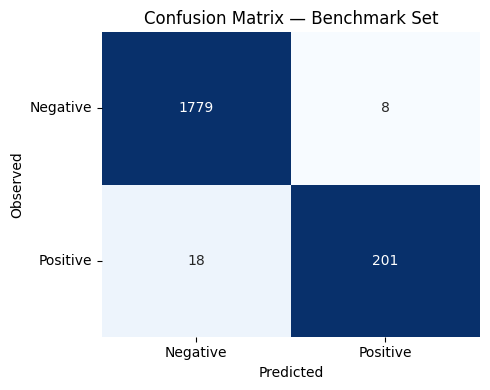

In [17]:
svm_mcc       = matthews_corrcoef(y_test, bench_pred)
svm_precision = precision_score(y_test, bench_pred)
svm_recall    = recall_score(y_test, bench_pred)
svm_accuracy  = accuracy_score(y_test, bench_pred)
conf_mat      = confusion_matrix(y_test, bench_pred)

print(f"MCC       : {svm_mcc:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"Accuracy  : {svm_accuracy:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d", cbar=False, vmax=200)
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title("Confusion Matrix — Benchmark Set")
plt.xticks([0.5, 1.5], ["Negative", "Positive"])
plt.yticks([0.5, 1.5], ["Negative", "Positive"], rotation=0)
plt.tight_layout()
plt.savefig("model_evaluation/Confusion_Matrix.png", dpi=300)
plt.show()

## 10. Helix Domain Analysis

Transmembrane proteins have hydrophobic segments that superficially resemble
signal peptides. We check whether False Positives are enriched for
HelixDomain proteins.

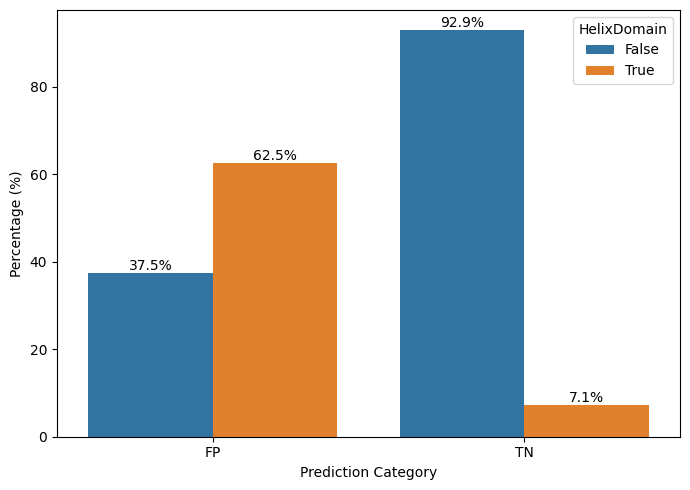

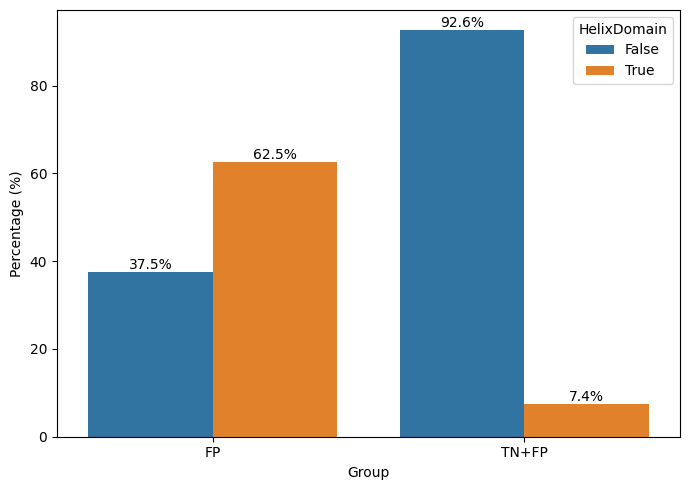

In [18]:
# Helix domain rate per prediction category
counts = (
    prediction_dataset.groupby(["Prediction", "HelixDomain"])
    .size().rename("n").reset_index()
)
counts["percent"] = counts.groupby("Prediction")["n"].transform(
    lambda s: s / s.sum() * 100
)
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts, x="Prediction", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Prediction Category")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation/HD_prediction_1.png", dpi=300)
plt.show()

# FP-only vs all Negatives — are FP enriched for helix domain proteins?
all_neg = prediction_dataset.query("Class == 'Negative'").copy()
all_neg["Group"] = "TN+FP"
fp_only = prediction_dataset.query("Prediction == 'FP'").copy()
fp_only["Group"] = "FP"
combined = pd.concat([fp_only, all_neg], ignore_index=True)

counts2 = combined.groupby(["Group", "HelixDomain"]).size().rename("n").reset_index()
counts2["percent"] = counts2.groupby("Group")["n"].transform(
    lambda s: s / s.sum() * 100
)
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts2, x="Group", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Group")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation/HD_prediction_2.png", dpi=300)
plt.show()

## 11. Signal Peptide Length Distribution

Do False Negatives (missed signals) tend to be shorter or longer than
True Positives? Atypical lengths may confuse the model.

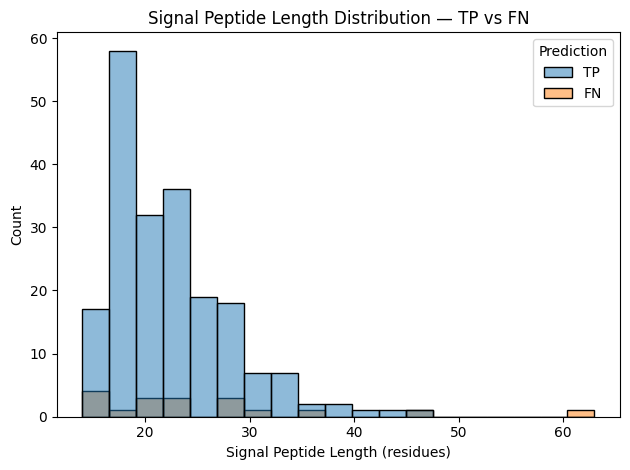

Mean SP length per prediction category:
Prediction
FN    26.00
TP    22.42
Name: sp_length, dtype: float64


In [19]:
length_df = prediction_dataset.query("Class == 'Positive'").copy()
length_df["sp_length"] = length_df["SPEnd"] - length_df["SPStart"]

sns.histplot(data=length_df, x="sp_length", hue="Prediction")
plt.title("Signal Peptide Length Distribution — TP vs FN")
plt.ylabel("Count")
plt.xlabel("Signal Peptide Length (residues)")
plt.tight_layout()
plt.savefig("model_evaluation/SP_length_distribution.png", dpi=300)
plt.show()

print("Mean SP length per prediction category:")
print(length_df.groupby("Prediction")["sp_length"].mean().round(2))

## 12. Hydrophobicity Analysis

The hydrophobic core is the defining feature of a signal peptide.
We compute Miyazawa-scale mean hydrophobicity over the annotated SP region
and compare TP vs FN distributions.

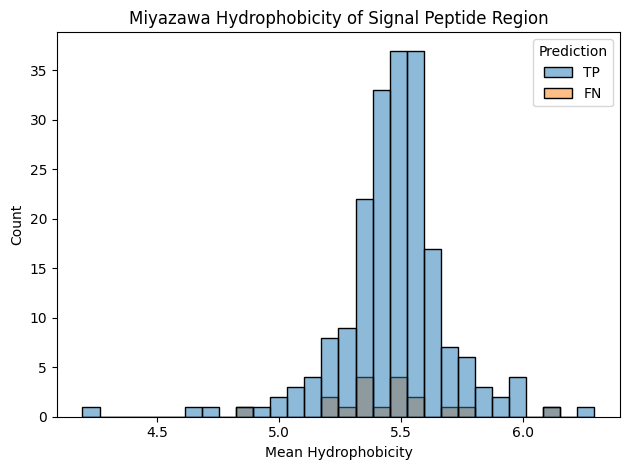

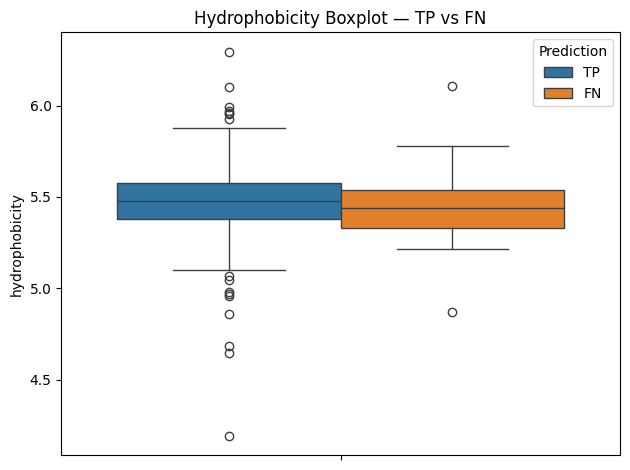

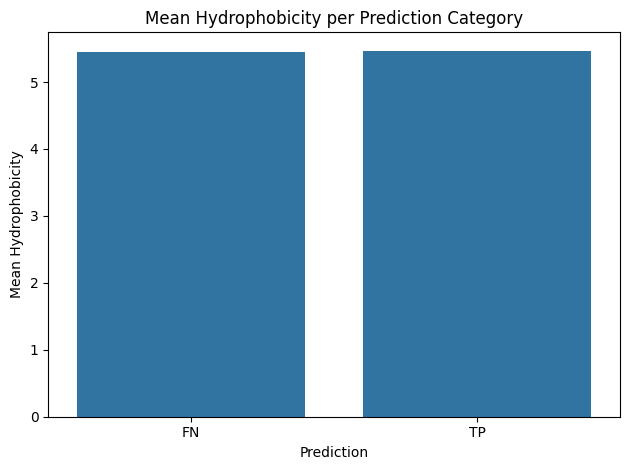


Mean hydrophobicity:
 Prediction
FN    5.4505
TP    5.4686
Name: hydrophobicity, dtype: float64


In [20]:
hydro_df = prediction_dataset.query("Class == 'Positive'").copy()
hydro_df["hydrophobicity"] = hydro_df.apply(
    lambda row: get_scale_feature(
        row["Sequence"], scale="mi",
        window=int(row["SPEnd"] - row["SPStart"]),
        output_type="mean",
    ), axis=1,
)

# Histogram
sns.histplot(data=hydro_df, x="hydrophobicity", hue="Prediction")
plt.title("Miyazawa Hydrophobicity of Signal Peptide Region")
plt.ylabel("Count")
plt.xlabel("Mean Hydrophobicity")
plt.tight_layout()
plt.savefig("model_evaluation/Hydrophobicity_SP.png", dpi=300)
plt.show()

# Boxplot
sns.boxplot(data=hydro_df, y="hydrophobicity", hue="Prediction")
plt.title("Hydrophobicity Boxplot — TP vs FN")
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_Hydrophobicity_SP.png", dpi=300)
plt.show()

# Group means
means = hydro_df.groupby("Prediction")["hydrophobicity"].mean()
sns.barplot(x=means.index, y=means.values)
plt.ylabel("Mean Hydrophobicity")
plt.title("Mean Hydrophobicity per Prediction Category")
plt.tight_layout()
plt.savefig("model_evaluation/Mean_hydrophobicity.png", dpi=300)
plt.show()
print("\nMean hydrophobicity:\n", means.round(4))

## 13. Amino Acid Frequency Analysis

Amino acids are grouped and colour-coded by physicochemical category:
🔵 Nonpolar · 🟠 Aromatic · 🟢 Polar · 🔴 Positive · 🟣 Negative

Three views:
- **13a** Full-sequence frequencies: TP vs FN  
- **13b** SP-region frequencies: TP vs FN  
- **13c** All groups: FP / FN / all Positives / all Negatives

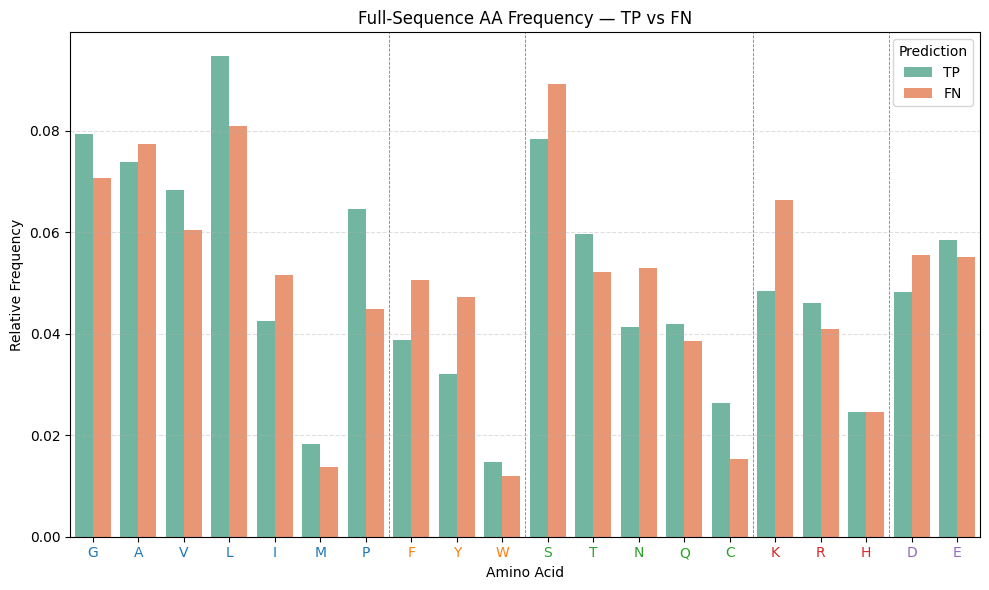

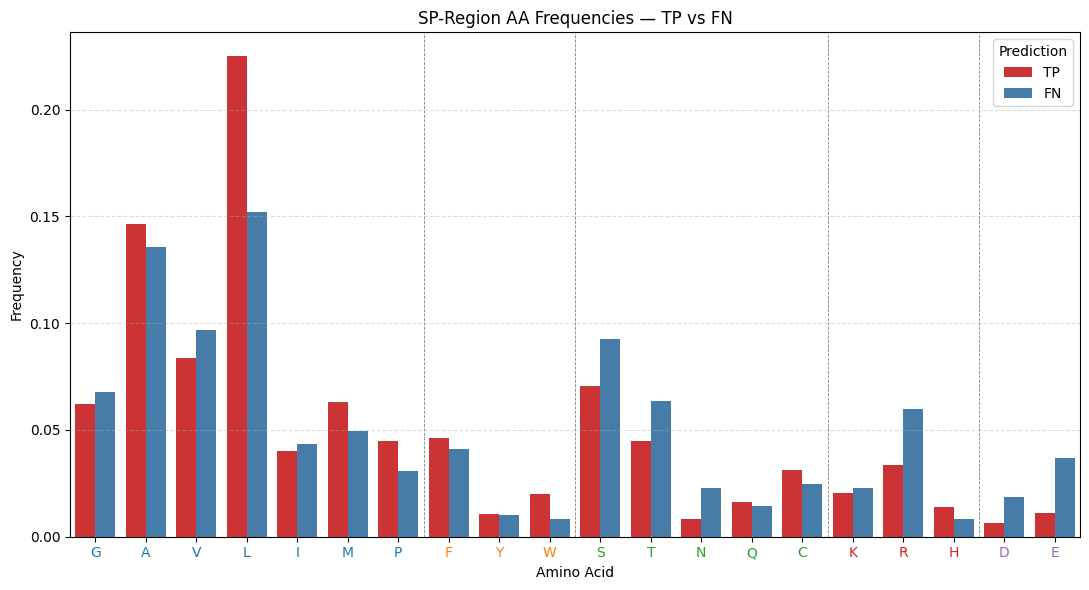

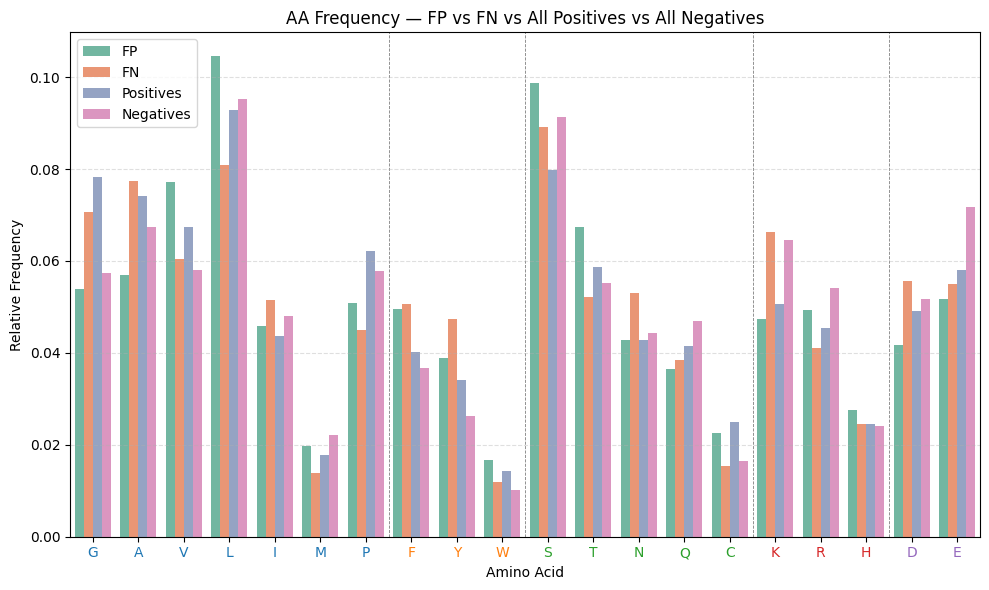

In [21]:
# ── Shared constants ─────────────────────────────────────────────────────────
AA_ORDER = [
    "G","A","V","L","I","M","P",    # nonpolar
    "F","Y","W",                     # aromatic
    "S","T","N","Q","C",             # polar
    "K","R","H",                     # positive
    "D","E",                         # negative
]
AA_CATEGORIES = {
    "nonpolar": list("GAVLIMP"), "aromatic": list("FYW"),
    "polar": list("STNQC"),     "positive": list("KRH"), "negative": list("DE"),
}
CAT_COLORS = {
    "nonpolar":"#1f77b4","aromatic":"#ff7f0e",
    "polar":"#2ca02c",  "positive":"#d62728","negative":"#9467bd",
}
RES_TO_CAT = {aa: cat for cat, aas in AA_CATEGORIES.items() for aa in aas}

def aa_frequency(df):
    """Normalised per-residue frequency across all sequences in df."""
    all_seq = "".join(df["Sequence"])
    total   = len(all_seq)
    return pd.Series({aa: all_seq.count(aa)/total for aa in set(all_seq)}).sort_index()

def group_boundaries():
    """X positions where amino-acid category groups change — used for divider lines."""
    bounds, current = [], None
    for i, aa in enumerate(AA_ORDER):
        cat = RES_TO_CAT[aa]
        if current is not None and cat != current:
            bounds.append(i - 0.5)
        current = cat
    return bounds

def style_aa_axis(ax):
    """Colour x-tick labels by amino-acid category and add divider lines."""
    for label in ax.get_xticklabels():
        cat = RES_TO_CAT.get(label.get_text())
        if cat:
            label.set_color(CAT_COLORS[cat])
    for x in group_boundaries():
        ax.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, zorder=0)

# ── 13a: Full-sequence TP vs FN ───────────────────────────────────────────────
tp_freq = aa_frequency(prediction_dataset[prediction_dataset["Prediction"]=="TP"][["Sequence"]])
fn_freq = aa_frequency(prediction_dataset[prediction_dataset["Prediction"]=="FN"][["Sequence"]])

aa_df = (
    pd.DataFrame({"TP": tp_freq, "FN": fn_freq}).fillna(0)
    .reset_index().melt(id_vars="index", var_name="Group", value_name="Frequency")
    .rename(columns={"index": "AminoAcid"})
)
aa_df["AminoAcid"] = pd.Categorical(aa_df["AminoAcid"], categories=AA_ORDER, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_df, x="AminoAcid", y="Frequency",
                 hue="Group", order=AA_ORDER, palette="Set2")
ax.set_title("Full-Sequence AA Frequency — TP vs FN")
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend(title="Prediction")
style_aa_axis(ax)
plt.tight_layout()
plt.savefig("model_evaluation/AA_frequencies_TP_vs_FN.png", dpi=300)
plt.show()

# ── 13b: SP-region TP vs FN ──────────────────────────────────────────────────
sp_df = prediction_dataset[prediction_dataset["Prediction"].isin(["TP","FN"])][
    ["SPStart","SPEnd","Sequence","Prediction"]].copy()
sp_df["SPSequence"] = sp_df.apply(
    lambda r: r["Sequence"][int(r["SPStart"])-1:int(r["SPEnd"])], axis=1)

def sp_freq(label):
    seqs = "".join(sp_df[sp_df["Prediction"]==label]["SPSequence"].dropna())
    if not seqs: return pd.Series(dtype=float)
    return pd.Series({aa: seqs.count(aa)/len(seqs) for aa in sorted(set(seqs))})

aa_df2 = (
    pd.DataFrame({"TP": sp_freq("TP"), "FN": sp_freq("FN")}).fillna(0)
    .reset_index().melt(id_vars="index", var_name="Group", value_name="Frequency")
    .rename(columns={"index": "AminoAcid"})
)
aa_df2["AminoAcid"] = pd.Categorical(aa_df2["AminoAcid"], categories=AA_ORDER, ordered=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=aa_df2, x="AminoAcid", y="Frequency",
                 hue="Group", order=AA_ORDER, palette="Set1")
ax.set_title("SP-Region AA Frequencies — TP vs FN")
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend(title="Prediction")
style_aa_axis(ax)
plt.tight_layout()
plt.savefig("model_evaluation/AA_frequencies_SP.png", dpi=300)
plt.show()

# ── 13c: FP / FN / all Positives / all Negatives ─────────────────────────────
groups = {
    "FP":        prediction_dataset[prediction_dataset["Prediction"]=="FP"][["Sequence"]],
    "FN":        prediction_dataset[prediction_dataset["Prediction"]=="FN"][["Sequence"]],
    "Positives": prediction_dataset[prediction_dataset["Class"]=="Positive"][["Sequence"]],
    "Negatives": prediction_dataset[prediction_dataset["Class"]=="Negative"][["Sequence"]],
}
aa_df3 = (
    pd.DataFrame({n: aa_frequency(d) for n, d in groups.items()}).fillna(0)
    .reset_index().melt(id_vars="index", var_name="Group", value_name="Frequency")
    .rename(columns={"index": "AminoAcid"})
)
aa_df3["AminoAcid"] = pd.Categorical(aa_df3["AminoAcid"], categories=AA_ORDER, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_df3, x="AminoAcid", y="Frequency",
                 hue="Group", order=AA_ORDER, palette="Set2")
ax.set_title("AA Frequency — FP vs FN vs All Positives vs All Negatives")
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend()
style_aa_axis(ax)
plt.tight_layout()
plt.savefig("model_evaluation/AA_frequency_Distribution.png", dpi=300)
plt.show()

## 14. Sequence Logos

Positional residue conservation around the cleavage site (Positives)
or N-terminal region (Negatives).
- **Information content**: height = conservation in bits (max 2 bits)
- **Probability**: height = residue usage frequency

<Figure size 600x400 with 0 Axes>

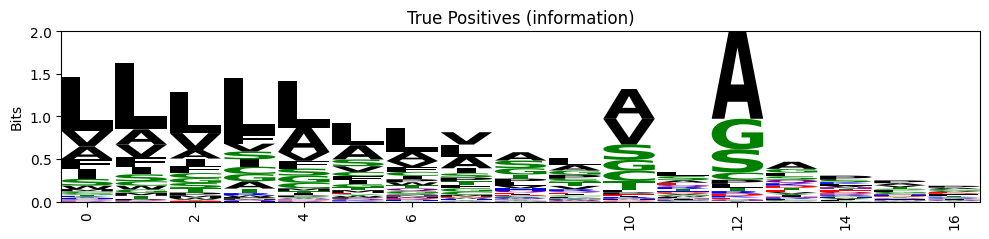

<Figure size 600x400 with 0 Axes>

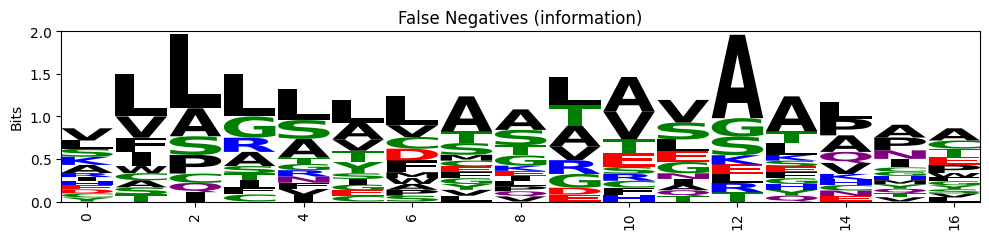

<Figure size 600x400 with 0 Axes>

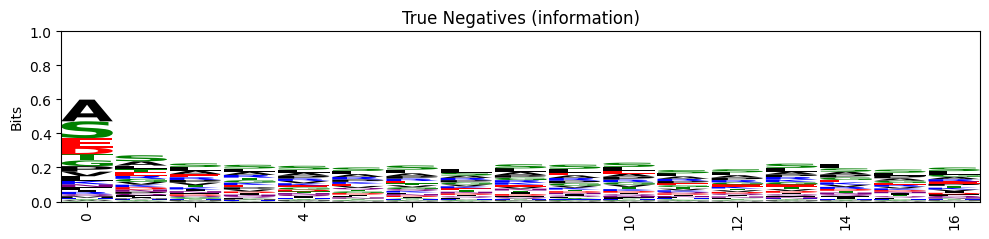

<Figure size 600x400 with 0 Axes>

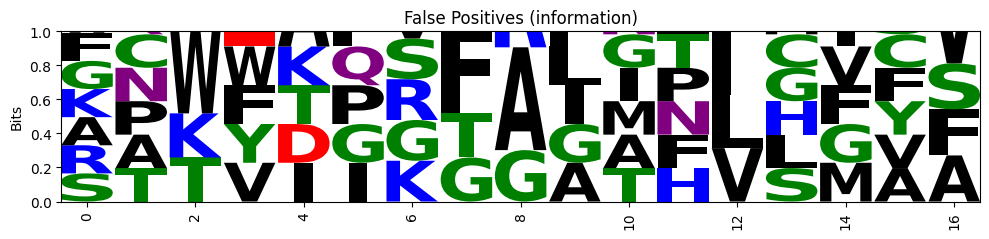

<Figure size 600x400 with 0 Axes>

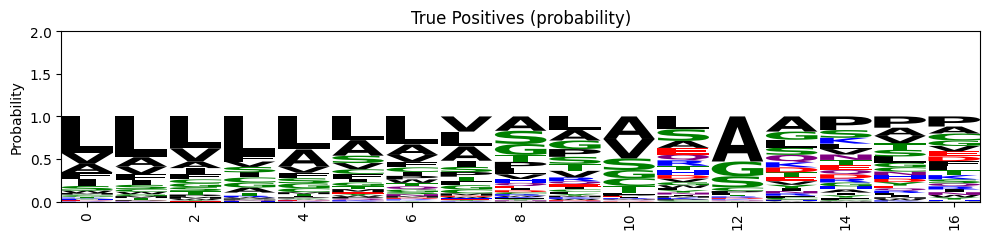

<Figure size 600x400 with 0 Axes>

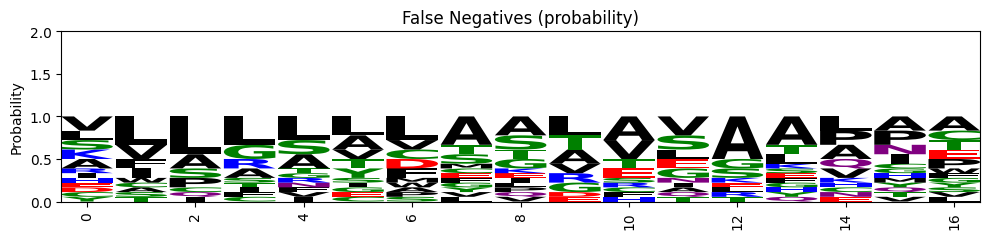

<Figure size 600x400 with 0 Axes>

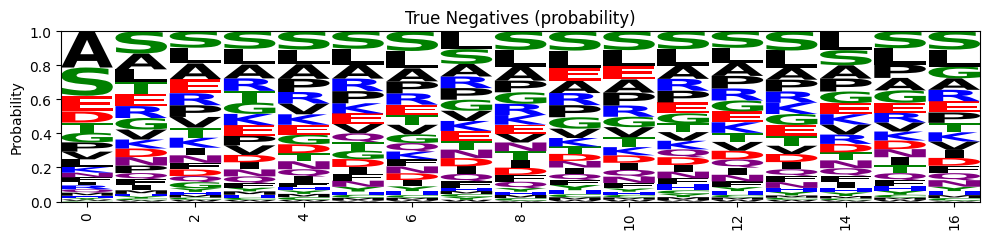

<Figure size 600x400 with 0 Axes>

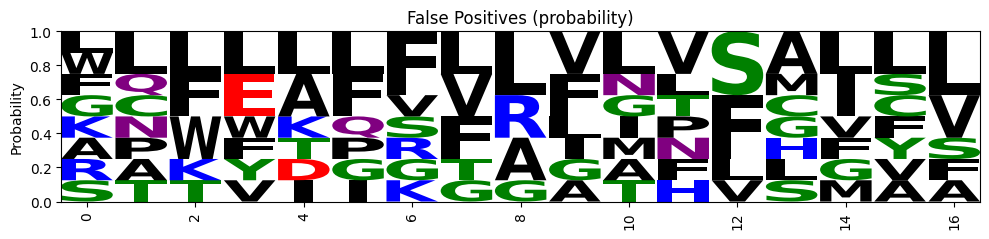

In [22]:
try:
    import logomaker as lm
    HAS_LOGOMAKER = True
except ImportError:
    print("logomaker not installed. Run: pip install logomaker")
    HAS_LOGOMAKER = False

if HAS_LOGOMAKER:
    logo_pos_seqs, logo_neg_seqs, logo_fn_seqs, logo_fp_seqs = [], [], [], []

    for _, row in prediction_dataset.query("Class == 'Positive'").iterrows():
        cp = int(row["SPEnd"])
        win = row["Sequence"][cp-13 : cp+4]
        logo_pos_seqs.append(win)
        if row["Prediction"] == "FN":
            logo_fn_seqs.append(win)

    for _, row in prediction_dataset.query("Class == 'Negative'").iterrows():
        win = row["Sequence"][1:18]
        logo_neg_seqs.append(win)
        if row["Prediction"] == "FP":
            logo_fp_seqs.append(win)

    groups = [
        (logo_pos_seqs, "True Positives"),
        (logo_fn_seqs,  "False Negatives"),
        (logo_neg_seqs, "True Negatives"),
        (logo_fp_seqs,  "False Positives"),
    ]

    for metric, ylabel, prefix in [
        ("information", "Bits",        "IC"),
        ("probability", "Probability", "Prob"),
    ]:
        for count, (seqs, label) in enumerate(groups, start=1):
            logo_mat = lm.alignment_to_matrix(
                sequences=seqs, to_type=metric,
                characters_to_ignore=".-X", pseudocount=0,
            )
            plt.figure(figsize=(6, 4))
            lm.Logo(logo_mat, shade_below=0.5, fade_below=0.5, color_scheme="chemistry")
            plt.xticks(rotation=90)
            plt.ylabel(ylabel)
            plt.ylim(0, 2.0 if label in ("True Positives","False Negatives") else 1.0)
            plt.title(f"{label} ({metric})")
            plt.tight_layout()
            plt.savefig(f"model_evaluation/SeqLogo_{prefix}_{count}.png", dpi=300)
            plt.show()

## 15. False Positive Rate

Global FPR and focused FPR for transmembrane (HelixDomain) proteins,
which are the most common source of false alarms for signal-peptide predictors.

In [23]:
n_fp      = len(prediction_dataset.query("Prediction == 'FP'"))
n_neg     = len(benchmark.query("Class == 'Negative'"))
fpr_all   = n_fp / n_neg

n_fp_hd  = len(prediction_dataset.query("Prediction == 'FP' and HelixDomain == True"))
n_neg_hd = len(benchmark.query("Class == 'Negative' and HelixDomain == True"))
fpr_hd   = n_fp_hd / n_neg_hd if n_neg_hd > 0 else float("nan")

print(f"FPR (all negatives)         : {fpr_all:.4f}")
print(f"FPR (HelixDomain negatives) : {fpr_hd:.4f}")

FPR (all negatives)         : 0.0045
FPR (HelixDomain negatives) : 0.0379


## 16. Taxonomic Analysis

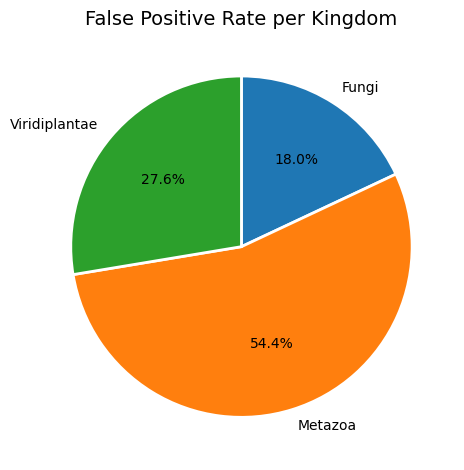

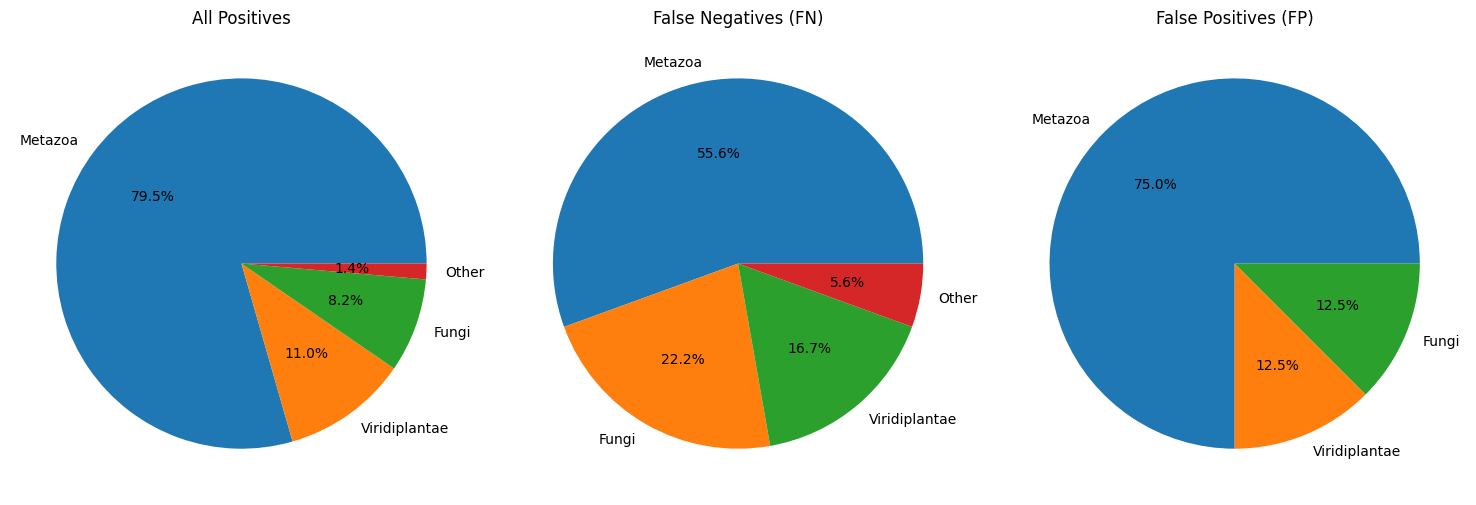

Viridiplantae entries        : 339
  of which Arabidopsis       : 243
FPR Viridiplantae (all)      : 0.0032
FPR Arabidopsis thaliana     : 0.0000
FPR other Viridiplantae      : 0.0135
FPR entire benchmark set     : 0.0045


In [24]:
# ── Per-kingdom FPR pie ───────────────────────────────────────────────────────
fp_df      = prediction_dataset.query("Prediction == 'FP'")
neg_counts = prediction_dataset.query("Class=='Negative'").groupby("Kingdom").size().rename("total_neg")
fp_counts  = fp_df.groupby("Kingdom").size().rename("fp_count")
kingdom_df = pd.concat([fp_counts, neg_counts], axis=1).dropna()
# FPR per kingdom = FP in that kingdom / all negatives in that kingdom
kingdom_df["percent"] = kingdom_df["fp_count"] / kingdom_df["total_neg"] * 100

fig, ax = plt.subplots()
ax.pie(kingdom_df["percent"], labels=kingdom_df.index, autopct="%.1f%%",
       startangle=90, counterclock=False,
       wedgeprops={"linewidth": 2, "edgecolor": "white"})
ax.set_title("False Positive Rate per Kingdom", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("model_evaluation/FPR_Kingdom.png", dpi=300)
plt.show()

# ── Taxonomic composition: all Positives / FN / FP ───────────────────────────
pos_df       = prediction_dataset.query("Class == 'Positive'")
counts_total = pos_df["Kingdom"].value_counts()
counts_fn    = pos_df[pos_df["Prediction"]=="FN"]["Kingdom"].value_counts()
counts_fp    = prediction_dataset[prediction_dataset["Prediction"]=="FP"]["Kingdom"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, counts, title in zip(axes,
    [counts_total, counts_fn, counts_fp],
    ["All Positives", "False Negatives (FN)", "False Positives (FP)"]):
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("model_evaluation/Pieplot_species.png", dpi=300)
plt.show()

# ── Viridiplantae deep-dive ───────────────────────────────────────────────────
plant_df = prediction_dataset.query("Kingdom == 'Viridiplantae'")

def safe_fpr(numerator_query, denominator_query):
    n = denominator_query.shape[0]
    return numerator_query.shape[0] / n if n > 0 else float("nan")

fpr_plant  = safe_fpr(plant_df.query("Prediction=='FP'"), plant_df.query("Class=='Negative'"))
ara        = plant_df.query("OrganismName == 'Arabidopsis thaliana'")
fpr_ara    = safe_fpr(ara.query("Prediction=='FP'"), ara.query("Class=='Negative'"))
non_ara    = plant_df.query("OrganismName != 'Arabidopsis thaliana'")
fpr_nonara = safe_fpr(non_ara.query("Prediction=='FP'"), non_ara.query("Class=='Negative'"))

print(f"Viridiplantae entries        : {plant_df.shape[0]}")
print(f"  of which Arabidopsis       : {ara.shape[0]}")
print(f"FPR Viridiplantae (all)      : {fpr_plant:.4f}")
print(f"FPR Arabidopsis thaliana     : {fpr_ara:.4f}")
print(f"FPR other Viridiplantae      : {fpr_nonara:.4f}")
print(f"FPR entire benchmark set     : {fpr_all:.4f}")